# Preliminaries

In [168]:
from dolfin import *
from ufl import indices, Jacobian, Min, Max, And, shape, replace
import numpy as np
import sys, os, pygmsh, gmsh, meshio, time

In [169]:
# plotting customizations
from matplotlib import pyplot as plt
from matplotlib import tri, colormaps, colors, cm
from mpl_toolkits.mplot3d import axes3d
size=18
params = {'legend.fontsize': size*0.75,
#          'figure.figsize': (20,8),
          'text.usetex': True,
          'text.latex.preamble': r'\usepackage{mathrsfs,bm}',
#          'mathtext.fontset': 'stix',
          'axes.labelsize': size,
          'axes.titlesize': size,
          'xtick.labelsize': size*0.875,
          'ytick.labelsize': size*0.875,
          'axes.titlepad': 25,
          'animation.embed_limit': 2**128}
plt.rcParams.update(params)
%matplotlib inline

## Credit

Based heavily on [fitted-fsi-example](https://github.com/david-kamensky/mae-207-fea-for-coupled-problems/tree/master/fsi) from David Kamensky's [MAE 207: FEA for coupled problems](https://github.com/david-kamensky/mae-207-fea-for-coupled-problems/tree/master) course at UC San Diego.

Rewrite by [Ivan C. Christov](http://christov.tmnt-lab.org), Purdue University (with input from Copilot) includes:
- converting to notebook format for easier on-the-fly analysis, 
- switching to gmsh for modern meshing,
- restricting to _steady flows_, 
- rewriting the FSI solver to be monolithic, 
- treating pressure inlet as Neumann BC, 
- implementing Carreau viscosity model for fluid,
- implementing 2D restriction of neo-Hookean solid,
- adding steady analytical solution comparisons,
- various other small improvements.

If you want to run this solver as a standalone python script (stripping all Markdown comments, etc), run the following command in your terminal:

`
jupyter nbconvert new_ALE-FSI_2D_steady.ipynb --to python --PythonExporter.exclude_markdown=True
`

which creates the file `new_ALE-FSI_2D_steady.py`.

## Introduction

Sketch of the geometry and notation.

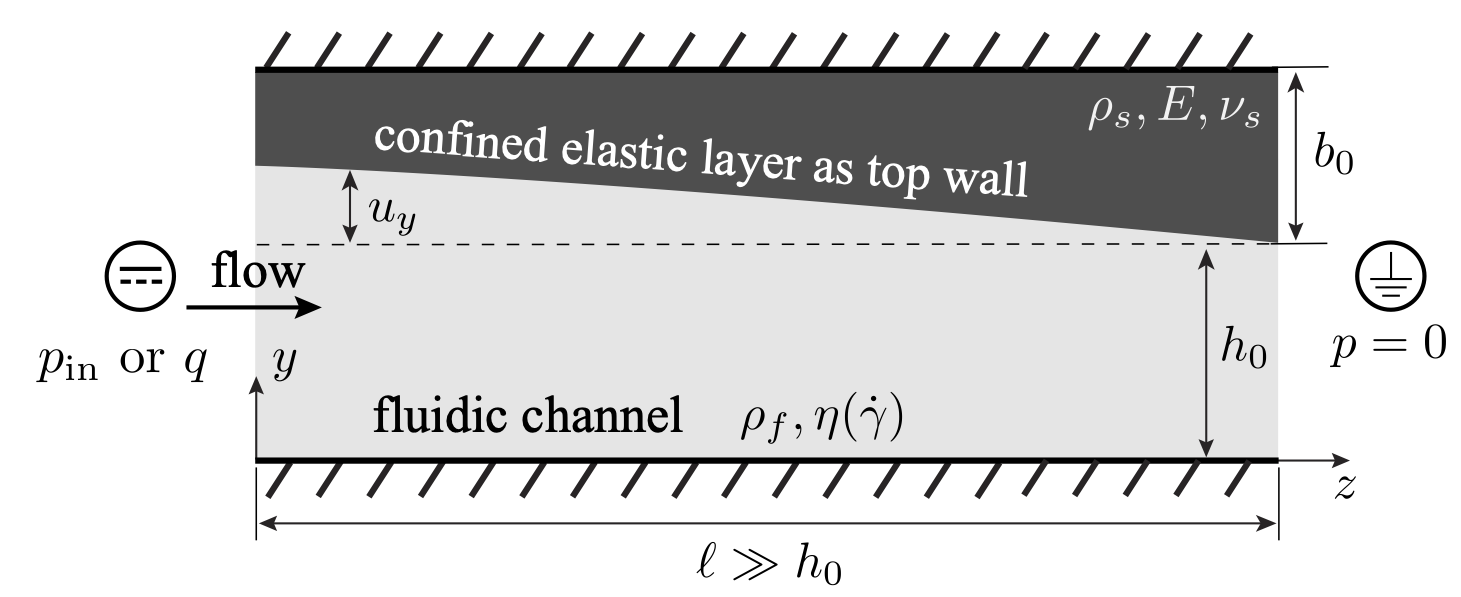

<span style="color: red">WARNING:</span> Carreau model is only implemented in the numerics. The theory relies on the power-law approximation &amp; Winkler-foundation elastic model.

# Problem setup

## Simulation settings

### Data storage

In [170]:
# If the folder does not exist, create it.
# I'm using a folder that will not get synced to GitHub.
DataFolder = "not-ready-for-github/simulation_output/"
if not os.path.exists(DataFolder):
    os.makedirs(DataFolder)
    print(f"CREATED data storage folder: {DataFolder}")
else:
    print(f"Using EXISTING data storage folder: {DataFolder}")

Using EXISTING data storage folder: not-ready-for-github/simulation_output/


### Algorithmic settings

Shouldn't require changing.

In [171]:
mesh_approach = "BLENDED"  # mesh elasticity approach; "SPLIT" or "BLENDED"
                           # should be equivalent but BLENDED seems more stable

LSIC          = False      # Least-squares incompressibility stabilization for fluid
BACKFLOW_STAB = True       # Backflow stabilization for fluid
SUPG          = False      # Streamline Upwind Petrov-Galerkin stabilization for fluid
                           # not needed for low Re flow

FLUID_MODE_ONLY = False    # A debugging option to run only fluid problem

print("============================ INFO ===========================")
print(f"Mesh elasticity approach: {mesh_approach}")
print(f"SUPG stabilization:       {'ON' if SUPG else 'OFF'}")
print(f"LSIC stabilization:       {'ON' if LSIC else 'OFF'}")
print(f"Backflow stabilization:   {'ON' if BACKFLOW_STAB else 'OFF'}")
if FLUID_MODE_ONLY:
    print("-------------------------------------------------------------")
    print("WARNING: Running in FLUID MODE ONLY (no solid coupling)")
print("=============================================================")

============================ INFO ===========================
Mesh elasticity approach: BLENDED
SUPG stabilization:       OFF
LSIC stabilization:       OFF
Backflow stabilization:   ON


### Parameters defining domain geometry

In [172]:
# Channel/wall dimensions (see figure):
h0 = 0.01
b0 = h0
l = 75*h0  # 50

# Desired resolution of mesh:
N = 100  # 600
# Refine near inlet in SOLID domain only?
inlet_refinement_solid_only = False
inlet_refinement = 0.5  # 1 = no refinement, 1/() times finer
# Refinement near fluid-solid interface
interface_refinement = 0.33  # 1 = no refinement, 1/() times finer

# Geometry-scale tolerance for subdomains:
d_tol = h0 * 1e-8

### Material properties (dimensional)

The solid is linearly elastic (with materia constants $E_s$, $\nu_s$).

The fluid is a generalized Newtonian fluid with shear-thinning behavior described by the Carreau model:
\begin{align*}
     \eta(\dot{\gamma}) 
     &= \eta_{\infty} + \left(\eta_0-\eta_{\infty}\right) \left[ 1 + (\lambda \dot{\gamma})^2 \right]^{(n-1)/2} \\
     &= \eta_{0} \left\{ \beta + (1-\beta) \left[ 1 + (\lambda \dot{\gamma})^2 \right]^{(n-1)/2} \right\} \\
     &= \eta_{0} \left\{ \beta + (1-\beta) |\lambda \dot{\gamma}|^{n-1} \right\}, \qquad |\lambda \dot{\gamma}| \gg 1 \\
     &= \eta_{0} |\lambda \dot{\gamma}|^{n-1}\qquad\qquad\;\;\; \beta \ll 1,\quad |\lambda \dot{\gamma}| \gg 1.
\end{align*}

In [173]:
# Elasticity model for real solid:
ELASTICITY_MODEL = "NEOH"  # "STVK" for St. Venant--Kirchhoff 
                           # "NEOH" for neo-Hookean, more robust than STVK

# Elastic solid's properties:
E_s    = 1e+5                           # Young's modulus
nu_s   = 0.45                           # Poisson ratio
mu_s   = Constant(E_s/(2*(1+nu_s)))     # Shear modulus
K      = Constant(E_s/(3*(1-2*nu_s)))   # Bulk modulus
rho_s0 = Constant(1e4)

# Viscous fluid properties to yield desired dimensionless numbers,
# based on dynamic similarity:
rho_f     = Constant(0.5)
eta_f_0   = Constant(1.0)   # 0.1
eta_f_inf = Constant(0.0)   # 0.01 or 0.0001
n         = Constant(1.0)   # 0.5
lam_r     = Constant(0.0)   # 10.0
# Consistency index for power-law approximation:
m_plaw    = eta_f_0*lam_r**(n-1) 

### Boundary conditions (analytical)

We use the analytical solution for the axial velocity in the _power-law regime_ from, e.g., "[Non-Newtonian fluid&ndash;structure interactions: Static response of a microchannel due to internal flow of a power-law fluid](https://dx.doi.org/10.1016/j.jnnfm.2018.12.008)" (preprint [arXiv:1809.09065](https://arxiv.org/arXiv:1809.09065)):
$$
    v_z(y) = \frac{h_0^{1+1/n}}{2^{1+1/n}(1+1/n)} \left(\frac{\Delta p}{\ell m}\right)^{1/n} \left(1-\left| \frac{2 y}{h_0}-1\right|^{1+1/n}\right) ,
$$
where $m = \eta_0 \lambda^{n-1}$, valid for $\beta = \eta_\infty/\eta_0 \ll 1$ and $|\lambda \dot{\gamma}| \sim Cu \gg 1$.

The flow rate&ndash;pressure drop relation in the rigid case is thus
$$
    q = \int_0^{h_0} v_z \, dy = \frac{1}{2^{1+1/n}(2 + 1/n)} \left(\frac{\Delta p}{\ell} \frac{h_0^{1 + 2n}}{m}\right)^{1/n} .
$$

In [174]:
# Steady pressure BC:
p_amp = Constant(2e5)
p_in = Expression("p0", p0=float(p_amp), degree=1)

# Steady flow-rate BC:
q_amp = Constant(0.025)
v_in = Expression(
    ("x[1] < h0 + eps ? "
    "-1/(1+1/n)*pow(h0/2,1+1/n)"
    "*pow((pow(2,1+1/n)*pow(h0,-2-1/n)*(1+2*n)*q0)/n,1/n)"
    "*(pow(abs(1-2*x[1]/h0),1+1/n)-1) : 0.0", "0.0"),
    q0=float(q_amp), 
    h0=float(h0),
    n=float(n),
    m_plaw=float(m_plaw),
    eps=d_tol, 
    degree=2
)

# Choose flow or pressure controlled BC:
FLOW_OR_PRESSURE = "FLOW"  # "FLOW" or "PRESSURE"
print(f"Using {FLOW_OR_PRESSURE}-controlled BC.")

# Allow ramp of load from 0 to full in steps to improve convergence
# of Newton solver (this uses previous solution as next 'guess').
# load_factors = [0.05, 0.2, 0.4, 0.5, 0.6, 0.7, 0.8, 0.85, 0.9, 1.0]
# load_factors = [0.1, 0.3, 0.7, 1.0]
load_factors = [1.0]
print(f"Load factor(s) for ramping BC: {load_factors}.")

Using FLOW-controlled BC.
Load factor(s) for ramping BC: [1.0].


### Dimensionless numbers

In [175]:
# Adjust scales for either flow rate or pressure control BC:
if FLOW_OR_PRESSURE == "FLOW":
    q_c = q_amp
    v_c = q_c/h0
    p_c = m_plaw*l*(q_c**n)/h0**(2*n+1)  #eta_f_0*q_c*l/h0**3
    dp_rigid = (2**(1+1/n)*(2+1/n))*float(p_c)
    q_rigid = float(q_c)
elif FLOW_OR_PRESSURE == "PRESSURE":
    p_c = p_amp
    q_c = ((p_c/l)*(h0**(2*n+1)/m_plaw))**(1/n) #(p_c/l)*(h0**3/eta_f_0)
    v_c = q_c/h0
    dp_rigid = float(p_c)
    q_rigid = float(q_c/(2**(1+1/n)*(2+1/n)))
else:
    raise ValueError("FLOW_OR_PRESSURE must be either 'FLOW' or 'PRESSURE'")

In [176]:
# Fluid (inverse) aspect ratio
epsilon_f = h0/l
# Solid (inverse) aspect ratio
epsilon_s = b0/l
# Incompressible foundation compliance
C_I = 2*nu_s*(nu_s-1/4)/(3*(1-nu_s)**2)*(b0**3/mu_s/l**2)
# Winkler foundation compliance
C_w = (1-2*nu_s)/(2*(1-nu_s))*(b0/mu_s)
# Horizontal component compliance
C_H = (nu_s-1/4)/(1-nu_s)*(b0**2/mu_s/l)
theta = float(C_I/C_w)
vartheta = float(C_H/C_w)
# Compliance number
alpha = float(p_c/(h0/C_w))
# Reynolds number
Re = float(epsilon_f * rho_f * v_c * h0/eta_f_0)
# Re = float(rho_f * epsilon_f**2 * h0**2 * p_c/eta_f_0**2)
# Carreau viscosity ratio
beta = float(eta_f_inf/eta_f_0)
# Carreau number
Cu = float(lam_r * v_c/h0)

print("============================ INFO ===========================")
print(f"ε_f = {epsilon_f:.5f}")
print(f"ε_s = {epsilon_s:.5f}")
print(f"θ   = {theta:.5f}")
print(f"α   = {alpha:.5f} (compliance #)")
print(f"εRe = {Re:.5f} (Reynolds #)")
print(f"β   = {beta:.5f} (Carreau viscosity ratio)")
print(f"Cu  = {Cu:.5f} (Carreau number)")
print("=============================================================")

============================ INFO ===========================
ε_f = 0.01333
ε_s = 0.01333
θ   = 0.00039
α   = 0.04943 (compliance #)
εRe = 0.00017 (Reynolds #)
β   = 0.00000 (Carreau viscosity ratio)
Cu  = 0.00000 (Carreau number)


## Analytical solutions: for comparisons, etc

### Rigid channel

Implementing the steady 2D channel flow solution for the pressure:
$$
    p(z) = \frac{\Delta p}{\ell}(\ell - z).
$$
The axial velocity is as given above.

In [177]:
# Note that "x" in v_in and/or p_in is really "y" in the kinematics,
# but, the mesh problem has a zero Dirichlet BC on the inflow boundary,
# forcing x = y there.

# x[1] < h0 is needed if we want to evaluate this
# over the whole Omega domain as an initial condition
p_rigid = Expression("x[1] < h0 + eps ? (dp/L)*(L-x[0]) : 0.0",
                     dp=float(p_amp), h0=float(h0), L=float(l), eps=d_tol, degree=1)
v_rigid = v_in

p_rigid.dp = float(dp_rigid)
v_rigid.q0 = float(q_rigid)

### Compliant channel

Implementing Eq. (41) and related results from "[Soft hydraulics: from Newtonian to complex fluid flows through compliant conduits](https://dx.doi.org/10.1088/1361-648X/ac327d)" (preprint [arXiv:2106.07164](https://arxiv.org/abs/2106.07164)):
$$
    %-\frac{dp}{d{z}} = \frac{2^{1+n}(2+1/n)^n m q^n}{[h_0 + \mathcal{C} p(z)]^{1+2n}w^n},
    -\frac{dp}{d{z}} = \frac{2^{1+n}(2+1/n)^n m q^n}{[h_0 + \mathcal{C} p(z)]^{1+2n}},\quad p(\ell) = 0,
$$
which can be integrated directly when $q$ is given (flow-rate control), or differentiated once and solved as 
$$
    \frac{d}{d{z}}\left\{ [h_0 + \mathcal{C} p(z)]^{1+2n} \frac{dp}{d{z}}  \right\} = 0,\quad p(0) = \Delta p,\quad p(\ell) = 0,
$$
when $\Delta p$ is given (pressure-drop control).

In [178]:
if FLOW_OR_PRESSURE == "FLOW":
    p_sh = Expression("pc/a*(pow(1 + nhat*a*(1.0-x[0]/L),1/(2+2*n)) - 1.0)",
                      pc=float(p_c), a=float(alpha), L=float(l), 
                      n=float(n), nhat=float(2**(1+n)*(2+1/n)**n*(2+2*n)), degree=1)
    q_sh = q_sh_in = q_sh_out = q_rigid
elif FLOW_OR_PRESSURE == "PRESSURE":
    p_sh = Expression("pc/a*(2**(1/(1+1/n))*(1+a)**2*((1+a)*2**(-1/(2*(1+n))))**(2*n)"
                      "*(1-x[0]/L) + x[0]/L, 1/(2+2*n)) - 1.0)",
                      pc=float(p_c), a=float(alpha), L=float(l), degree=4)
    # now the flow rate is found from the pressure gradient at z = 0
    factor = (1+alpha)**2*(2**(-(1/(2*(1+n))))*(1+alpha))**(2*n)
    dp_shdz0 = 2**(-2+1/(1+1/n))*(2**(1/(1+1/n))*factor)**(-1+1/(2+2*n)) \
               *(2**(1/(1+n))-2*factor)/(alpha*(n+1))
    # q = const and using Eq. (41) quoted above at z = 0
    q_sh = q_sh_in = q_sh_out = pow((-dp_shdz0)
                                    *((h0+C_w*p_sh(0))**(1+2*n)/m_plaw)
                                    /(2**(1+n)*(2+1/n)**n),1/n)
else:
    raise ValueError("FLOW_OR_PRESSURE must be either 'FLOW' or 'PRESSURE'")

## Domain and mesh

Gmsh-based geometry & mesh.

In [179]:
# Generate custom mesh with local refinements:
from build_mesh_with_gmsh import build_mesh_with_gmsh

xdmf_path = build_mesh_with_gmsh(N,
                                 [0.0, l, 0.0, h0+b0, b0],
                                 DataFolder+"fsi_rect",
                                 inlet_refinement=inlet_refinement,
                                 inlet_refinement_solid_only=inlet_refinement_solid_only,
                                 interface_refinement=interface_refinement)

# Load mesh back into dolfin from XDMF:
mesh = Mesh()
with XDMFFile(xdmf_path) as f:
    f.read(mesh)

# Mesh-derived quantities:
d = mesh.geometry().dim()
n_y = FacetNormal(mesh)
I = Identity(d)

Info    : Found interface curve 4: x = [-0.000000, 0.750000], y = 0.010000                                  
Info    : Meshing 1D...
Info    : [  0%] Meshing curve 1 (Line)
Info    : [ 20%] Meshing curve 2 (Line)
Info    : [ 30%] Meshing curve 3 (Line)
Info    : [ 50%] Meshing curve 4 (Line)
Info    : [ 60%] Meshing curve 5 (Line)
Info    : [ 80%] Meshing curve 6 (Line)
Info    : [ 90%] Meshing curve 7 (Line)
Info    : Done meshing 1D (Wall 0.165193s, CPU 0.252065s)
Info    : Meshing 2D...
Info    : [  0%] Meshing surface 2 (Plane, Frontal-Delaunay)
Info    : [ 60%] Meshing surface 3 (Plane, Frontal-Delaunay)
Info    : Done meshing 2D (Wall 0.0399902s, CPU 0.059255s)
Info    : 943 nodes 2134 elements
Info    : Writing 'not-ready-for-github/simulation_output/fsi_rect.msh'...
Info    : Done writing 'not-ready-for-github/simulation_output/fsi_rect.msh'



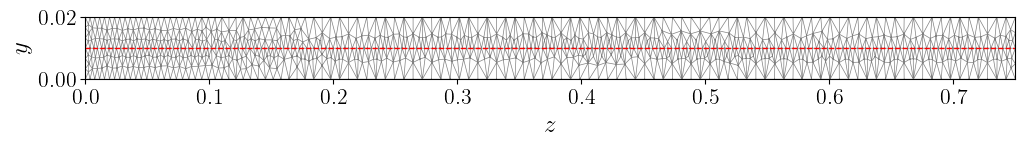

In [180]:
# Visualize the mesh real quick:
plot(mesh)
plt.gca().lines[0].set_linewidth(0.5)
plt.gca().set_aspect(2.5/1)
plt.gca().set_xlim(0, l)
plt.gca().set_xlabel("$z$")
plt.gca().set_ylabel("$y$")
plt.gca().set_ylim(0, h0+b0)
plt.gcf().set_size_inches(12, 6)
plt.plot(np.linspace(0, l, 10), np.ones(10)*(h0+b0)/2,
         linestyle='--', linewidth=1.0, color='red')
plt.show()

In [181]:
# Define subdomains for use in boundary condition definitions:
class Wall_b(SubDomain):
    def inside(self, x, on_boundary):
        return (on_boundary and near(x[1], 0.0))

class Wall_t(SubDomain):
    def inside(self, x, on_boundary):
        return (on_boundary and near(x[1], h0+b0, d_tol))

class Wall_l(SubDomain):
    def inside(self, x, on_boundary):
        return (on_boundary and near(x[0], 0.0)
                and (x[1] > h0 - d_tol))

class Wall_r(SubDomain):
    def inside(self, x, on_boundary):
        return (on_boundary and near(x[0], l, d_tol)
                and (x[1] > h0 - d_tol))

class Inflow(SubDomain):
    def inside(self, x, on_boundary):
        return (on_boundary and near(x[0], 0.0)
                and (x[1] < h0 + d_tol))

class Outflow(SubDomain):
    def inside(self, x, on_boundary):
        return (on_boundary and near(x[0], l, d_tol)
                and (x[1] < h0 + d_tol))

class SolidDomainClosure(SubDomain):
    def inside(self, x, on_boundary):
        return (x[1] > h0 - d_tol
                and x[1] < h0+b0 + d_tol
                and x[0] > 0.0 - d_tol
                and x[0] < l + d_tol)

class SolidDomainInterior(SubDomain):
    def inside(self, x, on_boundary):
        return (x[1] > h0 + d_tol  # exclude FS interface
                and x[1] < h0+b0 - d_tol
                and x[0] > 0.0 + d_tol
                and x[0] < l - d_tol)

class FluidDomainInterior(SubDomain):
    def inside(self, x, on_boundary):
        return (x[1] > 0 + d_tol  # exclude FS interface
                and x[1] < h0 - d_tol
                and x[0] > 0.0 + d_tol
                and x[0] < l - d_tol)

# Pressure pin-point at outlet to fix null space/gage
# (if needed):
class PressurePinPoint(SubDomain):
    def inside(self, x, on_boundary):
        return (near(x[0], l, d_tol) and near(x[1], 0.0))

# Fluid-solid interface (interior facets):
class FSInterface(SubDomain):
    def inside(self, x, on_boundary):
        return (near(x[1], h0, d_tol)
                and x[0] > 0.0 - d_tol
                and x[0] < l + d_tol)

In [182]:
# Markers:
markers = MeshFunction('size_t', mesh, d)
FLUID_FLAG, SOLID_FLAG = 0, 1  # defaults
markers.set_all(FLUID_FLAG)
SolidDomainClosure().mark(markers, SOLID_FLAG)

# Facet markers (0 = default):
facet_tags = MeshFunction('size_t', mesh, d-1, 0)

# Mark the no-slip walls:
NS_WALLS = 6
Wall_b().mark(facet_tags, NS_WALLS)
Wall_t().mark(facet_tags, NS_WALLS)
# Mark solid domain walls:
S_WALLS = 7
Wall_l().mark(facet_tags, S_WALLS)
Wall_r().mark(facet_tags, S_WALLS)

# Then, mark inlet and outlet facets
# Overwrites inflow/outflow on the fluid portion:
INFLOW, OUTFLOW = 3, 2
Inflow().mark(facet_tags, INFLOW)
Outflow().mark(facet_tags, OUTFLOW)

# Mark fluid–solid interface facets:
INTERFACE = 5
FSInterface().mark(facet_tags, INTERFACE)

# Increase quadrature order to be safe:
qd = 5
# Quadrature-aware exterior measures:
ds = ds(metadata={'quadrature_degree': qd},
        domain=mesh, subdomain_data=facet_tags)
dS = dS(metadata={'quadrature_degree': qd},
        domain=mesh, subdomain_data=facet_tags)
# Quadrature-aware interior measures:
dx = dx(metadata={'quadrature_degree': qd},
        domain=mesh, subdomain_data=markers)

In [183]:
# Check exterior (in/outlet) and interior (interface) measures:
print("======================== DIAGNOSTICS ========================")
print("Checking identification of boundary surfaces ...")
print("|Γ_in|  =", float(assemble(1.0 * ds(INFLOW))), '; h0 = ', h0)
print("|Γ_out| =", float(assemble(1.0 * ds(OUTFLOW))), '; h0 = ', h0)
print("|Γ_fs|  =", float(assemble(1.0 * dS(INTERFACE))), '; l =', l)

# Check whether '+' or '-' is the fluid side:
V0 = FunctionSpace(mesh, "DG", 0)
chi_f = interpolate(Constant(0.0), V0)
# --- Build a DG0 indicator chi_f == 1 in fluid cells, 0 in solid cells ---
V0 = FunctionSpace(mesh, "DG", 0)
chi_f = Function(V0)
chi = np.zeros(V0.dim())
dofmap0 = V0.dofmap()
for c in range(mesh.num_cells()):
    sub_id = markers.array()[c]             # FLUID_FLAG or SOLID_FLAG
    dof = dofmap0.cell_dofs(c)[0]           # DG0 has one dof per cell
    chi[dof] = 1.0 if sub_id == FLUID_FLAG else 0.0
chi_f.vector().set_local(chi)
chi_f.vector().apply("")
Lm = assemble(chi_f('-') * dS(INTERFACE))
Lp = assemble(chi_f('+') * dS(INTERFACE))

print()
print("Checking which side of Γ_fs is fluid ...")
print("if (-) is fluid, Γ_fs length =", Lm)
print("if (+) is fluid, Γ_fs length =", Lp)
print("=> (-) is fluid side" if Lm > Lp else "=> (+) is fluid side")
print("=============================================================")

======================== DIAGNOSTICS ========================
Checking identification of boundary surfaces ...
|Γ_in|  = 0.009999999999999998 ; h0 =  0.01
|Γ_out| = 0.009999999999999998 ; h0 =  0.01
|Γ_fs|  = 0.7499999999999993 ; l = 0.75

Checking which side of Γ_fs is fluid ...
if (-) is fluid, Γ_fs length = 0.0
if (+) is fluid, Γ_fs length = 0.7499999999999993
=> (+) is fluid side


# Variational problem definitions

## Elements, function spaces, and variables

In [184]:
# Mixed function space for the monolithic fluid-structure problem:
cell = mesh.ufl_cell()
Ve = VectorElement("CG", cell, 2)   # velocity-like or displacement-like
Qe = FiniteElement("CG", cell, 1)   # pressure, 1 degree lower

Ze = MixedElement([Ve, Qe, Ve])  # (v, p, u)
Z = FunctionSpace(mesh, Ze)

# Monolithic unknown vector:
z = Function(Z)
(v, p, u) = split(z)
(dv, dp, du) = TestFunctions(Z)

## ALE kinematics (change of variables)

In [185]:
# Follow notation from Bazilevs et al., where y is
# the coordinate in the reference domain, x is the
# coordinate in the spatial domain, and X is the
# coordinate in the material domain.  Note that
# the built-in differential operators (e.g., grad,
# div, etc.) and integration measures (e.g., dx, ds,
# etc.) are w.r.t. the reference configuration, y,
# which is the mesh that FEniCS sees.
dy = dx
grad_y = grad

y = SpatialCoordinate(mesh)
x = y + u

det_dxdy = det(grad_y(x))

def grad_x(f):
    return dot(grad_y(f), inv(grad_y(x)))

def div_x(f):  # (For vector-valued f)
    return tr(grad_x(f))

def div_x_tens(f):  # (For (rank-2) tensor-valued f)
    i, j = indices(2)
    return as_tensor(grad_x(f)[i, j, j], (i,))

# Note:  Trying to define dx = det_dxdy*dy would
# result in an object of type Form, which could no
# longer be used as an integration measure.
# Thus, integration over the spatial configuration
# is done with det_dxdy*dy directly in the fluid
# formulation.

## Boundary conditions (simulation)

In [186]:
# Start with a clean slate of boundary conditions:
bcs = []

# Fluid velocity walls: v = 0 on top/bottom/left/right above the fluid height:
bcs_f = [DirichletBC(Z.sub(0), Constant((0.0, 0.0)), facet_tags, NS_WALLS),
         DirichletBC(Z.sub(0), Constant((0.0, 0.0)), facet_tags, S_WALLS),
         DirichletBC(Z.sub(0), Constant((0.0, 0.0)), SolidDomainInterior(), method='pointwise')]

# Fluid velocity FS interface: v = 0 in steady flow (no mesh motion):
# In legacy FEniCS, DirichletBC is guaranteed on exterior facets,
# while interior sets are best enforced pointwise on the interface DoF coordinates.
bcs_if = [DirichletBC(Z.sub(0), Constant((0.0, 0.0)),
                      FSInterface(), method='pointwise')]

# Inlet BC:
if FLOW_OR_PRESSURE == "FLOW":
    bcs_in = [DirichletBC(Z.sub(0), v_in, facet_tags, INFLOW)]
elif FLOW_OR_PRESSURE == "PRESSURE":
    # will be imposed as Neumann BC via consistent traction below
    bcs_in = []
    # DO NOT ENFORCE PRESSURE AS DIRICHLET!
    # bcs_in = [DirichletBC(Z.sub(1), p_in, facet_tags, INFLOW)]
else:
    raise ValueError("FLOW_OR_PRESSURE must be either 'FLOW' or 'PRESSURE'")

# Pressure pinning / outlet pressure BC is unnecessary but possible:
# bcs_p = [DirichletBC(Z.sub(1), Constant(0.0), facet_tags, OUTFLOW)]
# bcs_p = [DirichletBC(Z.sub(1), Constant(0.0), PressurePinPoint(), method='pointwise')]

# We use pressure pinning inside solid domain to match velocity BCs there:
bcs_p = [DirichletBC(Z.sub(1), Constant(0.0), SolidDomainInterior())]

# Mesh/solid zero displacement BCs on external boundaries:
bcs_s = [DirichletBC(Z.sub(2), Constant((0.0, 0.0)), facet_tags, NS_WALLS),
         DirichletBC(Z.sub(2), Constant((0.0, 0.0)), facet_tags, S_WALLS),
         DirichletBC(Z.sub(2), Constant((0.0, 0.0)), facet_tags, INFLOW),
         DirichletBC(Z.sub(2), Constant((0.0, 0.0)), facet_tags, OUTFLOW)]

In [187]:
print("======================== DIAGNOSTICS ========================")
# Verify pressure pin BC
print(f"Pressure pin BC affects {bcs_p[0].get_boundary_values().__len__()} DOF(s).")
# Verify Dirichlet interface BC
if bcs_if:
    print(f"Γ_fs velocity Dirichlet BC affects {bcs_if[0].get_boundary_values().__len__()} DOF(s).")
print("=============================================================")

======================== DIAGNOSTICS ========================
Pressure pin BC affects 230 DOF(s).
Γ_fs velocity Dirichlet BC affects 978 DOF(s).


## Monolithic residual

### Solid and mesh (elasticity) subproblems

In [188]:
# Deformation gradient and strain tensor:
F_s = F_m = I + grad_y(u)
E_s = 0.5*(F_s.T*F_s - I)

# Real solid's stress:
if ELASTICITY_MODEL == "STVK":
    S_solid = K*tr(E_s)*I + 2.0*mu_s*(E_s - tr(E_s)*I/3.0)
elif ELASTICITY_MODEL == "NEOH":
    # Neo-Hookean, W = (mu_s/2)*(I1 - 3) - mu_s*ln(J) + (lam/2)*(ln(J))^2
    # Isochoric-volumetric Neo-Hookean (preferred for nu close to 0.5)
    J_s = det(F_s)
    C = F_s.T * F_s
    # Note that I1_3D = I1_2D + C_xx = I1_2D + 1 (plane strain):
    I1  = tr(C) + Constant(1.0)
    Cinv = inv(C)
    # 2nd Piola-Kirchhoff stress:
    S_iso = mu_s * J_s**Constant(-2.0/3.0) * (I - Constant(1.0/3.0)*I1*Cinv)
    S_vol = K * (J_s - Constant(1.0)) * J_s * Cinv
    S_solid = S_iso + S_vol
else:
    raise ValueError("Unknown value of ELASTICITY_MODEL!")

# Stiffnesses for mesh motion (weak, but not TOO weak):
mesh_stiffness_factor = Constant(1.0)  # 3*alpha #Constant(0.25)
m_jac_stiff_pow = 3.0
K_m = mesh_stiffness_factor / pow(det(F_m), m_jac_stiff_pow)
mu_m = mesh_stiffness_factor / pow(det(F_m), m_jac_stiff_pow)
# Mesh's "stress" (currently, always St. Venant--Kirchhoff):
S_mesh = K_m*tr(E_s)*I + 2.0*mu_m*(E_s - tr(E_s)*I/3.0)

# Should be equivalent with either SPLIT or BLENDED approach:
if mesh_approach == "SPLIT":
    res_s_solid = inner(F_s*S_solid, grad(du)) * dx(SOLID_FLAG)
    res_s_mesh = inner(F_s*S_mesh, grad(du)) * dx(FLUID_FLAG)
    res_s = res_s_solid + res_s_mesh

elif mesh_approach == "BLENDED":
    one = interpolate(Constant(1.0), V0)
    chi_s = one - chi_f   # 1 in solid, 0 in fluid
    S_blend = chi_s * S_solid + chi_f * S_mesh
    res_s = inner(F_s*S_blend, grad(du)) * dx  # Note minus sign!

### Fluid subproblem


In [189]:
# Shear rate helper function:
def gamma_dot(v):
    E_f = sym(grad_x(v))
    return sqrt(2.0*inner(E_f, E_f) + DOLFIN_EPS)

# Effective viscosity (Carreau model):
def mu_eff(v):
    return eta_f_inf + (eta_f_0 - eta_f_inf) \
        * (1.0 + (lam_r*gamma_dot(v))**2.0)**((n-1.0)/2.0)

# Cauchy stress of the fluid:
sigma_f = 2.0*mu_eff(v)*sym(grad_x(v)) - p*I

# Convective term of the fluid:
vhat = Constant((0.0,)*mesh.geometry().dim())     # steady ALE mesh velocity
v_adv = (v - vhat)
DvDt = dot(grad_x(v), v_adv)                      # steady convective term
# DvDt  = Constant((0.0,)*mesh.geometry().dim())   # Stokes flow

# Galerkin residual for steady incompressible Navier–Stokes eqs:
resGal_f = (rho_f*dot(DvDt, dv)
            + inner(sigma_f, grad_x(dv))
            + dp*div_x(v))*det_dxdy*dx(FLUID_FLAG)

# NOT-INTEGRATED-BY-PARTS FORM (for reference):
# resGal_f = ( rho_f*dot(DvDt, dv)
#              - inner(div_x_tens(sigma_f), dv)
#              + dp*div_x(v) )*det_dxdy*dx(FLUID_FLAG)

# Deformed mesh size tensor in the spatial configuration:
J_m = Jacobian(mesh)
dxi_dy = inv(J_m)
dxi_dx = dxi_dy*inv(grad_y(x))
G = (dxi_dx.T)*dxi_dx

# Stabilization (steady SUPG/PSPG + LSIC/grad-div) with small eps:
resStrong_f = rho_f*DvDt - div_x_tens(sigma_f)

Cinv = Constant(1.0)
tau_M = 1.0/sqrt(inner(rho_f*v_adv, G*(rho_f*v_adv))
                 + Cinv*(eta_f_0**2)*inner(G, G) + DOLFIN_EPS)
tau_C = 1.0/(tr(G)*tau_M + DOLFIN_EPS)

resSUPG_f = inner(tau_M*resStrong_f, rho_f*dot(grad_x(dv), v_adv)
                  + grad_x(dp))*det_dxdy*dx(FLUID_FLAG)

resLSIC_f = tau_C*div_x(v)*div_x(dv)*det_dxdy*dx(FLUID_FLAG)

# Total fluid residual:
res_f = resGal_f
# and stabilization terms as needed:
if SUPG:
    res_f += resSUPG_f
if LSIC:
    res_f += resLSIC_f
# Backflow-stable outlet Neumann (outlet only):
if BACKFLOW_STAB:
    dsx_dsy_n_x = det_dxdy*inv(F_m.T)*n_y
    v_adv_minus = Min(dot(v_adv, dsx_dsy_n_x), Constant(0.0))
    gm = Constant(1.0)
    resOutflow_f = -gm*dot(rho_f*v_adv_minus*dv, v)*ds(OUTFLOW)
    res_f += resOutflow_f
# Add consistent traction at inlet to enforce pressure as Neumann BC:
if FLOW_OR_PRESSURE == "PRESSURE":
    # Traction on reference boundary mapped to spatial configuration
    # by Nanson's formula:
    traction = det_dxdy*inv(F_m.T)*(-p_in*n_y)
    res_f += -inner(traction, dv)*ds(INFLOW)

### Coupling

Traction at interface enforces the FS coupling. Contribution from solid onto fluid vanishes because ... ?

In [190]:
# Physical traction from fluid in reference configuration:
F_fluid = F_m('+')
J_fluid = det(F_fluid)
sigma_fluid = sigma_f('+')
P_fluid = J_fluid * sigma_fluid * inv(F_fluid.T)
t_ref = P_fluid * n_y('+')

# '-' when res_s if '+' (integration by parts x -1)
res_if = -inner(t_ref, du('-')) * dS(INTERFACE)

Define total residuals and complete set of BCs to solve with.

In [191]:
if FLUID_MODE_ONLY:
    res = res_f
    bcs = bcs_f + bcs_in + bcs_p + bcs_if

    # Robust anchors for u since we have no solid mechanics:
    hmin = mesh.hmin()  # ok to use here; we turn it into numeric constants
    alpha_u0 = Constant(1e3 * float(eta_f_0) / hmin)    # mass-like anchor on u
    alpha_u1 = Constant(1e2 * float(eta_f_0))           # gradient anchor on u
    res += alpha_u0 * inner(u,  du) * dx \
        + alpha_u1 * (hmin**2) * inner(grad(u), grad(du)) * dx
else:
    res = res_f + res_s + res_if
    bcs = bcs_f + bcs_in + bcs_p + bcs_s + bcs_if

# Nonlinear solver for the monolithic problem

Nonlinear solver settings; this is _extremely_ tricky.

In [192]:
# Start fresh:
PETScOptions.clear()

# Force direct solver -- helps a lot for monolithic FSI:
PETScOptions.set("ksp_type", "preonly")
PETScOptions.set("pc_type", "lu")
PETScOptions.set("pc_factor_mat_solver_type", "mumps")
PETScOptions.set("mat_mumps_icntl_8", 77)          # Key: automatic scaling
PETScOptions.set("mat_mumps_icntl_24", 1)          # null pivot detection
# Sequential ordering for stability
PETScOptions.set("mat_mumps_icntl_13", 1)
PETScOptions.set("mat_mumps_cntl_1", 0.001)        # Small pivot threshold
# PETScOptions.set("mat_mumps_icntl_14", 100)       # Increase working space
PETScOptions.set("pc_factor_shift_amount", 1e-10)  # Small pivot shift
PETScOptions.set("pc_factor_shift_type", "NONZERO")

# Tolerances:
PETScOptions.set("snes_rtol", 1e-6) # or 1e-5
PETScOptions.set("snes_atol", 1e-8) # or 1e-6
# PETScOptions.set("snes_stol", 1e-10)
PETScOptions.set("snes_max_it", 50)

# Error handling:
# Allow it to fail without throwing an error, so that 
# it makes the plots after the solve (even if wrong, used for debugging).
PETScOptions.set("snes_error_if_not_converged", 0)
PETScOptions.set("ksp_error_if_not_converged", 0)

# Line search:
PETScOptions.set("snes_type", "newtonls")
PETScOptions.set("snes_linesearch_type", "bt")     # backtracking
# PETScOptions.set("snes_type", "newtontr")         # trust-region
PETScOptions.set("snes_linesearch_damping", 0.8)
PETScOptions.set("snes_linesearch_order", 3)
PETScOptions.set("snes_linesearch_max_it", 10)
PETScOptions.set("snes_max_linear_solve_fail", 10)

# Monitors/logging (optional):
PETScOptions.set("snes_monitor")
# PETScOptions.set("ksp_monitor")
PETScOptions.set("snes_converged_reason")
# PETScOptions.set("ksp_converged_reason")
# PETScOptions.set("snes_test_jacobian")
set_log_level(LogLevel.INFO)
# CRITICAL, ERROR, WARNING, INFO, PROGRESS, TRACE, DBG

In [193]:
# Nonlinear problem and solver:
problem = NonlinearVariationalProblem(res, z, bcs, derivative(res, z))
solver = NonlinearVariationalSolver(problem)

# Configure solver:
solver.parameters['nonlinear_solver'] = 'snes'

Solve monolithic system. 🤞 This is where the magic happens!

In [194]:
# Initialize solution vector to zero:
z.vector()[:] = 0.0

# Project rigid solution into the vector as initial guess:
# (if desired, but doesn't seem to help convergence)
# Vv = Z.sub(0).collapse()
# Vp = Z.sub(1).collapse()
# Vu = Z.sub(2).collapse()

# v0 = project(v_rigid, Vv)
# p0 = project(p_rigid, Vp)
# u0 = Function(Vu); u0.vector()[:] = 0.0

# assigner_v = FunctionAssigner(Z.sub(0), Vv)
# assigner_p = FunctionAssigner(Z.sub(1), Vp)
# assigner_u = FunctionAssigner(Z.sub(2), Vu)

# assigner_v.assign(z.sub(0), v0)
# assigner_p.assign(z.sub(1), p0)
# assigner_u.assign(z.sub(2), u0)

print("="*60, flush=True)
print(f"Starting nonlinear solve with {z.vector().size()} DOFs.", flush=True)
print("="*60, flush=True)

error = False
for index, load_factor in enumerate(load_factors):
    print(f"\n{'-'*60}", flush=True)
    print(f"Trying load factor = {load_factor} ...", flush=True)
    print(f"{'-'*60}", flush=True)

    # Scale the inlet BC
    if FLOW_OR_PRESSURE == "FLOW":
        v_in.q0 = load_factor * float(q_amp)
    elif FLOW_OR_PRESSURE == "PRESSURE":
        p_in.p0 = load_factor * float(p_amp)

    # Save last working solution in case we need it after a solve() failure:
    z_last_working = z.copy(deepcopy=True)

    try:
        solver.solve()
    except RuntimeError as e:
        print("\n" + "="*60, flush=True)
        print(f"Caught a RuntimeError: {e}", flush=True)
        print(
            f"\n\n\n \u26A0\uFE0F Failed on load factor: {load_factor} \u26A0\uFE0F", flush=True)
        print(
            f"\n\n \u26A0\uFE0F Last load factor before failure: {load_factors[index-1]} \u26A0\uFE0F", flush=True)
        print("\n\n \u26A0\uFE0F WARNING: FULL LOAD _NOT_ REACHED \u26A0\uFE0F", flush=True)
        print("\n" + "="*60, flush=True)
        error = True
        break

    # Use previous solution as initial guess for next load
    # (z already contains the solution)

# Sleep for 1 s  to make sure all the print statements are flushed:
time.sleep(1)
print()

if not error:
    print(f"{'='*60}", flush=True)
    print("  >>>SUCCESS<<< Full load reached! \U0001F389 \U0001F389 \U0001F389", flush=True)
    print(f"{'='*60}", flush=True)

Starting nonlinear solve with 15083 DOFs.

------------------------------------------------------------
Trying load factor = 1.0 ...
------------------------------------------------------------
Solving nonlinear variational problem.
  0 SNES Function norm 4.974967466438e+01
  1 SNES Function norm 4.587403119387e+01
  2 SNES Function norm 4.424665103244e+01
  3 SNES Function norm 4.015903408077e+01
  4 SNES Function norm 2.552625348989e+01
  5 SNES Function norm 5.219202259077e+00
  6 SNES Function norm 1.047552204362e+00
  7 SNES Function norm 2.096532344378e-01
  8 SNES Function norm 4.193631472366e-02
  9 SNES Function norm 8.387489309237e-03
 10 SNES Function norm 1.677506913578e-03
 11 SNES Function norm 3.355017446604e-04
 12 SNES Function norm 6.710036343950e-05
 13 SNES Function norm 1.342007291759e-05
  Nonlinear solve converged due to CONVERGED_FNORM_RELATIVE iterations 13
  PETSc SNES solver converged in 13 iterations with convergence reason CONVERGED_FNORM_RELATIVE.

  >>>SU

In [195]:
# Extract named fields for output and plotting below:
v, p, u = z.split(True)

# Output to file (PVD format):
# v.rename("v", "v"); p.rename("p", "p"); u.rename("u", "u")
# vfile = File(DataFolder + "velocity.pvd")
# pfile = File(DataFolder + "pressure.pvd")
# mfile = File(DataFolder + "mesh.pvd")
# vfile << v; pfile << p; mfile << u

### Diagnostics

In [196]:
# Mesh Jacobian checks:
J_mesh = project(det(grad_y(y+u)), FunctionSpace(mesh, "DG", 0))
J_vals = J_mesh.vector()[:]

# Mass conservation on the fluid boundaries:
Q_in = assemble(dot(v, dsx_dsy_n_x) * ds(INFLOW))
Q_out = assemble(dot(v, dsx_dsy_n_x) * ds(OUTFLOW))
Q_wall = assemble(dot(v, dsx_dsy_n_x) * ds(NS_WALLS))
Q_walls = assemble(dot(v, n_y) * ds(NS_WALLS))
Q_FS = assemble(dot(v('-'), n_y('-')) * dS(INTERFACE))
sum_Q = float(Q_in + Q_out + Q_walls + Q_FS)

# Some div v diagnostics:
mass_residual = assemble(det_dxdy * div_x(v) * dx(FLUID_FLAG))

div_L2 = assemble(div_x(v)**2 * det_dxdy * dx(FLUID_FLAG))**0.5
fluid_volume = assemble(det_dxdy * dx(FLUID_FLAG))
div_rms = div_L2 / sqrt(fluid_volume)

V0 = FunctionSpace(mesh, "DG", 0)
divv = project(div_x(v), V0)

# Kinematic mismatch on Γ_fs (should be small):
slip = sqrt(assemble(inner(v('-'), v('-')) * dS(INTERFACE)))

# Pressure diagnostics:
x_test = np.array([0.0, l/3, l/2, 2*l/3, l])
p_computed = [p(xi, h0/2) for xi in x_test]
p_theory = [p_sh(xi, h0/2) for xi in x_test]

print("======================== DIAGNOSTICS ========================")
print(f"det(F) min: {J_vals.min():.6f}            |  "
      f"det(F) max: {J_vals.max():.6f}")
print(f"Number of inverted elements: {sum(J_vals < 0)}  |  "
      f"Number near-inverted (J < 0.3): {sum(J_vals < 0.3)}")

# Where is the problem?
if J_vals.min() < 0.3:
    bad_cells = np.where(J_vals < 0.3)[0]
    print(f"Problematic cells: {bad_cells[:10]}")  # First 10

    # Get coordinates of bad cells
    V0 = FunctionSpace(mesh, "DG", 0)
    coords = V0.tabulate_dof_coordinates()
    for cell_id in bad_cells[:5]:
        print(
            f"  Cell {cell_id} at ({coords[cell_id, 0]:.4f}, {coords[cell_id, 1]:.4f})")

print()
print(f"Q_in    = {q_rigid:.12e}   (rigid)")
print(f"Q_in    = {float(q_sh):.12e}   (soft hydraulic theory)")
print(f"Q_in    = {Q_in:.12e}  (sim, expect < 0),  ",
      f"% err={100.0*abs(-Q_in-float(q_sh))/abs(float(q_sh)):.2f}%")
print(f"Q_out   = {Q_out:.12e}   (sim, expect > 0),  ",
      f"% err={100.0*abs(Q_out-float(q_sh))/abs(float(q_sh)):.2f}%")
print(f"Q_walls = {Q_walls:.12e}   (≈ 0 with no-slip)")
print(f"Q_FS    = {Q_FS:.12e}   (≈ 0 if BC imposed strongly)")

print()
# print("Global mass conservation residuals:")
print(f"Σ Q :         {sum_Q:.6e} (target: < 1e-6)")
# print(f"Relative imbalance: {abs(Q_in + Q_out)/abs(Q_in):.6e} (target: < 1e-4)")
print(f"∫ div(v) dΩ : {abs(mass_residual):.6e} (target: < 1e-8)")

print()
print(
    f"FS interface kinematic mismatch ||v||_Γfs = {float(slip)} (should be ≈ 0)")

# Interpolate the inlet profile to the velocity space restricted on the inflow
v_in_V = interpolate(v_in, Z.sub(0).collapse())

# Compute L2 mismatch *on the inflow boundary* (via boundary integral of full vector)
if FLOW_OR_PRESSURE == "FLOW":
    mismatch_vec = assemble(inner(v - v_in_V, v - v_in_V) * ds(INFLOW))
    print()
    print("inlet velocity profile mismatch (only small if imposing v BC)")
    print(f"||v - v_in||_L2(Γ_in) = {mismatch_vec**0.5:.6e}")

print()
print(f"p_inlet  = {p_rigid(0, h0):.4f} Pa (rigid)")
print(f"p_inlet  = {p_theory[0]:.4f} Pa (soft hydraulics (plaw))")
print(f"p_inlet  = {p_computed[0]:.4f} Pa (sim)")
print()
print("Pressure (p/p_c) comparisons at interface y=h_0:")
print(f"  x=0:    sim={p_computed[0]/float(p_c):5g},",
      f"soft hydraulics (plaw)={p_theory[0]/float(p_c):5g},",
      f"% err={100.0*abs(p_computed[0]-p_theory[0])/abs(p_theory[0]):.2f}%")
print(f"  x=l/3:  sim={p_computed[1]/float(p_c):5g},",
      f"soft hydraulics (plaw)={p_theory[1]/float(p_c):5g},",
      f"% err={100.0*abs(p_computed[1]-p_theory[1])/abs(p_theory[1]):.2f}%")
print(f"  x=l/2:  sim={p_computed[2]/float(p_c):5g},",
      f"soft hydraulics (plaw)={p_theory[2]/float(p_c):5g},",
      f"% err={100.0*abs(p_computed[2]-p_theory[2])/abs(p_theory[2]):.2f}%")
print(f"  x=2l/3: sim={p_computed[3]/float(p_c):5g},",
      f"soft hydraulics (plaw)={p_theory[3]/float(p_c):5g},",
      f"% err={100.0*abs(p_computed[3]-p_theory[3])/abs(p_theory[3]):.2f}%")
# print(f"  x=l:    sim={p_computed[4]/float(p_c):5g}, theory={p_theory[4]/float(p_c):5g}")
print("=============================================================")

======================== DIAGNOSTICS ========================
det(F) min: 0.671167            |  det(F) max: 1.413444
Number of inverted elements: 0  |  Number near-inverted (J < 0.3): 0

Q_in    = 2.500000000000e-02   (rigid)
Q_in    = 2.500000000000e-02   (soft hydraulic theory)
Q_in    = -2.499999889408e-02  (sim, expect < 0),   % err=0.00%
Q_out   = 2.499999889408e-02   (sim, expect > 0),   % err=0.00%
Q_walls = 0.000000000000e+00   (≈ 0 with no-slip)
Q_FS    = 0.000000000000e+00   (≈ 0 if BC imposed strongly)

Σ Q :         -2.775558e-16 (target: < 1e-6)
∫ div(v) dΩ : 3.347375e-16 (target: < 1e-8)

FS interface kinematic mismatch ||v||_Γfs = 0.0 (should be ≈ 0)

inlet velocity profile mismatch (only small if imposing v BC)
||v - v_in||_L2(Γ_in) = 1.211475e-08

p_inlet  = 225000.0000 Pa (rigid)
p_inlet  = 134721.4628 Pa (soft hydraulics (plaw))
p_inlet  = 137662.4060 Pa (sim)

Pressure (p/p_c) comparisons at interface y=h_0:
  x=0:    sim=7.34199, soft hydraulics (plaw)=7.18514, % 

# Visualization and post-processing

Some meshing preliminaries. 

We make horizontal scales dimensionless by dividing by $\ell$, and vertical scales dimensionless by dividing by $h_0+b_0$.

In [197]:
# Extract coordinates and displacement values:
coordinates = mesh.coordinates()
cells = mesh.cells()
dim = mesh.geometry().dim()
num_vertices = len(coordinates)

# Create triangulation and plot:
x_coords = coordinates[:, 0]/l
y_coords = coordinates[:, 1]/(h0+b0)
triang = tri.Triangulation(x_coords, y_coords, cells)

## Inlet/outlet flow rates

In [198]:
# Post-process the inlet and outlet flow rates:
Qin1 = assemble(dot(v, n_y)*ds(INFLOW))/float(q_c)
Qout1 = assemble(dot(v, n_y)*ds(OUTFLOW))/float(q_c)

# Dirichlet conditiosn on u at INLET and OUTLET make these equivalent:
Qin2 = assemble(dot(v, dsx_dsy_n_x)*ds(INFLOW))/float(q_c)
Qout2 = assemble(dot(v, dsx_dsy_n_x)*ds(OUTFLOW))/float(q_c)

Qtheory = float(q_sh/q_c)

print("Dim'less inlet Q (normal):", f"{Qin1:.6g}",
      ", (Nanson):", f"{Qin2:.6g}",
      ", theory:", f"{-Qtheory:.6g}")
print("Dim'less outlet Q (normal):", f"{Qout1:.6g}",
      ", (Nanson):", f"{Qout2:.6g}",
      ", theory:", f"{Qtheory:.6g}")

Dim'less inlet Q (normal): -1 , (Nanson): -1 , theory: -1
Dim'less outlet Q (normal): 1 , (Nanson): 1 , theory: 1


## Height-averaged axial pressure distribution

In [199]:
# Sampling parameters:
num_x_samples = 50
num_y_samples = 100
x_vals = np.linspace(0.0, l, num_x_samples)
y_line = np.linspace(0.0, h0, num_y_samples)

# Cross-sectional averages via line integrals (trapz along y at fixed x).
# More accurate than strip-indicator approach: no area-averaging artefacts,
# no DG0/CG1 indicator mismatch, proper 1/h0 normalisation.

# Sampling d, dp/dx, d2p/dx2:
avg_p = np.array([
    np.trapezoid([p(float(xi), float(yj)) for yj in y_line], y_line) / h0
    for xi in x_vals
])

# If needed, d/dx and d2/dx2 axial derivatives 
# via central differences (O(Δx²) interior):
# avg_dpdx   = np.gradient(avg_p,    x_vals)
# avg_d2pdx2 = np.gradient(avg_dpdx, x_vals)

# Rigid-channel and soft-hydraulic reference pressures:
pressure_rigid = np.array([p_rigid(float(xi), 0.0) for xi in x_vals])
pressure_sh    = np.array([p_sh(float(xi),    0.0) for xi in x_vals])

Reminder: compliance #, α = 0.04943


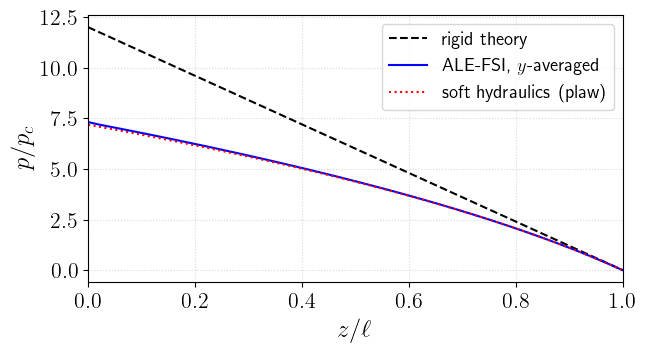

In [200]:
# Create plot:
fig, ax = plt.subplots(tight_layout=True)
ax.plot(x_vals/l, pressure_rigid/float(p_c),
        label='rigid theory', linestyle='dashed', color='black')
ax.plot(x_vals/l, avg_p/float(p_c),
        label='ALE-FSI, $y$-averaged', color='blue')
ax.plot(x_vals/l, pressure_sh/float(p_c),
        label='soft hydraulics (plaw)', linestyle='dotted', color='red')

ax.set_xlabel(r'$z/\ell$')
ax.set_ylabel('$p/p_c$')
ax.grid(alpha=0.5, linestyle='dotted')

ax.legend()

ax.set_xlim(0, 1)
# ax.set_ylim(0, pressure_rigid[0]/float(p_c))
# ax.set_yticks(np.arange(0,pressure_rigid[0]/float(p_c)+0.1,2))
# ax.set_aspect(1)
ax.set_box_aspect(1 / 2)

print(f"Reminder: compliance #, α = {alpha:.5f}")

plt.show()

## Fluid&ndash;solid interface displacement and pressure

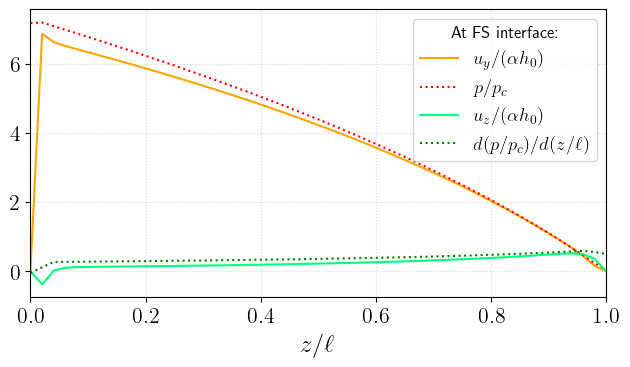

In [201]:
# Create points along the fluid-solid interface:
# (offset down by ~1/N if needed, to ensure we're in the fluid domain)
fs_line_points = [(x, h0) for x in x_vals]

# Evaluate the vertical displacement and pressure at each point:
u_fs_values = np.array([u(point) for point in fs_line_points])
p_fs_values = np.array([p(point) for point in fs_line_points])
# d/dx and d2/dx2 axial derivatives via central differences, O(Δx²):
dpdx_fs     = np.gradient(p_fs_values, x_vals)
d2pdx2_fs   = np.gradient(dpdx_fs, x_vals)

# Create plot:
fig, ax = plt.subplots(tight_layout=True)
ax.plot(x_vals/l, u_fs_values[:, 1]/float(alpha*h0),
        label=r'$u_y/(\alpha h_0)$', color='orange')
ax.plot(x_vals/l, p_fs_values/float(p_c),
        label='$p/p_c$', color='red', linestyle='dotted')
ax.plot(x_vals/l, u_fs_values[:, 0]/float(alpha*h0),
        label=r'$u_z/(\alpha h_0)$', color='springgreen')
ax.plot(x_vals/l, -vartheta*dpdx_fs/(float(p_c)/l), 
        label=r'$d(p/p_c)/d(z/\ell)$', color='green', linestyle='dotted')

ax.set_xlabel(r'$z/\ell$')
# ax.set_ylabel()
ax.grid(alpha=0.5, linestyle='dotted')

ax.legend(title="At FS interface:", title_fontsize='large')

ax.set_xlim(0, 1)
# ax.set_ylim(0, pressure_rigid[0]/float(p_c))
# ax.set_yticks(np.arange(0,pressure_rigid[0]/float(p_c)+0.1,2))
# ax.set_aspect(1)
ax.set_box_aspect(1 / 2)

plt.show()

## Pressure contours

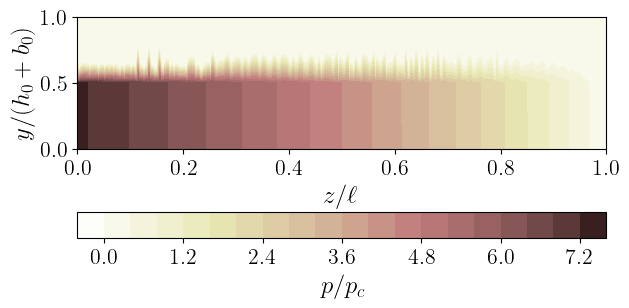

In [202]:
# Get pressure values at vertices:
pressure_values = p.compute_vertex_values(mesh)

# Create plot:
fig, ax = plt.subplots(tight_layout=True)
contour = ax.tricontourf(triang, pressure_values/float(p_c),
                         levels=20, cmap='pink_r')
fig.colorbar(contour, label='$p/p_c$', orientation='horizontal')

ax.set_xlabel(r'$z/\ell$')
ax.set_ylabel(r'$y/(h_0+b_0)$')

ax.set_aspect(1 / 4)

plt.show()

## Fluid velocity magnitude contours

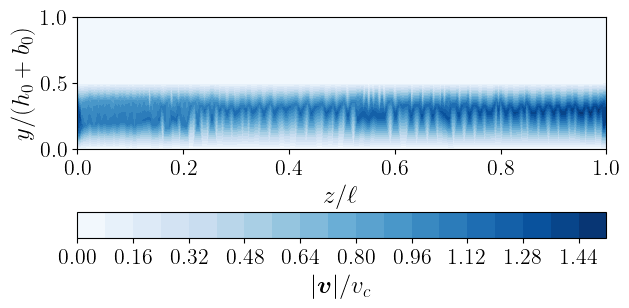

In [203]:
# Get velocity values at vertices:
vx, vy = v.split()
vx_values = vx.compute_vertex_values(mesh)
vy_values = vy.compute_vertex_values(mesh)

# Compute magnitude:
magnitude = np.sqrt(vx_values**2 + vy_values**2)

# Create plot:
fig, ax = plt.subplots()
contour = ax.tricontourf(triang, magnitude/float(v_c),
                         levels=20, cmap='Blues')
cb = fig.colorbar(contour, orientation='horizontal')
if params['text.usetex']:
    cb.set_label(r'$|\bm{v}|/v_c$')
else:
    cb.set_label(r'$|\vec{v}|/v_c$')

ax.set_xlabel(r'$z/\ell$')
ax.set_ylabel(r'$y/(h_0+b_0)$')

ax.set_aspect(1 / 4)

plt.tight_layout()
plt.show()

## Displacement magnitude contours

We can mask all $y/h_0 < h_0/(h_0+b_0)$ to show only the displacement fiend in the solid. There is mesh displacement in the fluid domain but we do not consider that to be "physical."

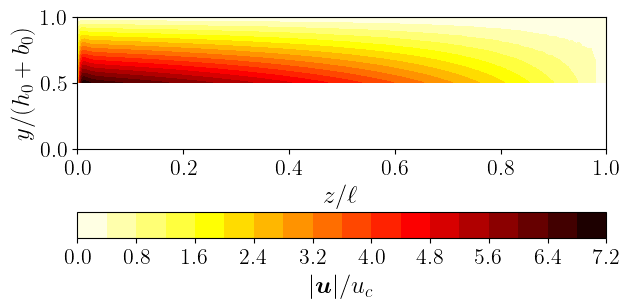

In [204]:
# Get displacement values at vertices:
ux, uy = u.split()
ux_values = ux.compute_vertex_values(mesh)
uy_values = uy.compute_vertex_values(mesh)

# Compute magnitude:
magnitude = np.sqrt(ux_values**2 + uy_values**2)
# Mask off fluid domain, need to deep copy the triang:
masked_triang = tri.Triangulation(x_coords.copy(),
                                  y_coords.copy(),
                                  cells.copy())
masked_triang.set_mask(
    np.mean(y_coords[masked_triang.triangles], axis=1) < h0/(h0+b0))

# Create plot:
fig, ax = plt.subplots(tight_layout=True)
contour = ax.tricontourf(masked_triang, magnitude/float(alpha*h0),
                         levels=20, cmap='hot_r')

cb = fig.colorbar(contour, orientation='horizontal')
if params['text.usetex']:
    cb.set_label(r'$|\bm{u}|/u_c$')
else:
    cb.set_label(r'$|\vec{u}|/u_c$')

ax.set_xlabel(r'$z/\ell$')
ax.set_ylabel(r'$y/(h_0+b_0)$')

ax.set_aspect(1 / 4)

plt.show()